# Relax Take-Home Analysis

## 0. Environment and Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

## 1. Load Data

In [2]:
users = pd.read_csv("data/takehome_users.csv", encoding='latin-1')
engagement = pd.read_csv("data/takehome_user_engagement.csv")

## 2. Inspect and Clean Data

In [3]:
# Inspect users dataset

print('HEAD:\n', users.head())
print('\nSAMPLE:\n', users.sample(n=5, random_state=42))
print('\nSHAPE:\n', users.shape)
print('\nINFO:')
users.info()
print('\nDESCRIBE STRING:\n', users.describe(include='str').T)
print('\nDESCRIBE NUMERIC:\n', users.describe().T)
print('\nNULL COUNTS:\n', users.isnull().sum().sort_values(ascending=False))


HEAD:
    object_id        creation_time               name  \
0          1  2014-04-22 03:53:30     Clausen August   
1          2  2013-11-15 03:45:04      Poole Matthew   
2          3  2013-03-19 23:14:52  Bottrill Mitchell   
3          4  2013-05-21 08:09:28    Clausen Nicklas   
4          5  2013-01-17 10:14:20          Raw Grace   

                        email creation_source  last_session_creation_time  \
0    AugustCClausen@yahoo.com    GUEST_INVITE                1.398139e+09   
1      MatthewPoole@gustr.com      ORG_INVITE                1.396238e+09   
2  MitchellBottrill@gustr.com      ORG_INVITE                1.363735e+09   
3   NicklasSClausen@yahoo.com    GUEST_INVITE                1.369210e+09   
4          GraceRaw@yahoo.com    GUEST_INVITE                1.358850e+09   

   opted_in_to_mailing_list  enabled_for_marketing_drip  org_id  \
0                         1                           0      11   
1                         0                           0    

In [4]:
# Inspect engagement dataset
print('HEAD:\n', engagement.head())
print('\nSAMPLE:\n', engagement.sample(n=5, random_state=42))
print('\nSHAPE:\n', engagement.shape)
print('\nINFO:')
engagement.info()
print('\nDESCRIBE STRING:\n', engagement.describe(include='str').T)
print('\nDESCRIBE NUMERIC:\n', engagement.describe().T)
print('\nNULL COUNTS:\n', engagement.isnull().sum().sort_values(ascending=False))


HEAD:
             time_stamp  user_id  visited
0  2014-04-22 03:53:30        1        1
1  2013-11-15 03:45:04        2        1
2  2013-11-29 03:45:04        2        1
3  2013-12-09 03:45:04        2        1
4  2013-12-25 03:45:04        2        1

SAMPLE:
                  time_stamp  user_id  visited
178853  2013-12-06 08:44:30    10100        1
180791  2013-05-07 08:38:26    10238        1
23069   2014-04-22 14:48:05     1368        1
28115   2013-04-19 05:43:47     1769        1
1411    2013-09-20 10:15:18       69        1

SHAPE:
 (207917, 3)

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   time_stamp  207917 non-null  str  
 1   user_id     207917 non-null  int64
 2   visited     207917 non-null  int64
dtypes: int64(2), str(1)
memory usage: 4.8 MB

DESCRIBE STRING:
              count  unique                  top freq
time_stamp  2079

In [5]:
# Clean date columns
users['creation_time'] = pd.to_datetime(users['creation_time'])
users['last_session_creation_time'] = pd.to_datetime(
    users['last_session_creation_time'], 
    unit='s',
    errors='coerce'
)
engagement['time_stamp'] = pd.to_datetime(engagement['time_stamp'])
engagement['date'] = engagement['time_stamp'].dt.date

## 3. Define Adopted Users

In [6]:
# Adopted = logged in on 3 separate days within any 7-day period

def is_adopted(group):
    dates = (
        pd.Series(pd.to_datetime(group["date"].unique()))
        .sort_values()
        .reset_index(drop=True)
    )
    
    if len(dates) < 3:
        return 0
    
    for i in range(len(dates) - 2):
        if (dates[i + 2] - dates[i]).days <= 7:
            return 1
    
    return 0

adopted = (
    engagement
    .groupby("user_id")
    .apply(is_adopted)
    .reset_index(name="adopted_user")
)



In [7]:
print(adopted['adopted_user'].value_counts(), '\n')
print(adopted.head())


adopted_user
0    7167
1    1656
Name: count, dtype: int64 

   user_id  adopted_user
0        1             0
1        2             1
2        3             0
3        4             0
4        5             0


## 4. Merge `users` and `adopted` dataframes

In [8]:
# Merge adopted label into users table

df_merged = users.merge(
    adopted,
    how="left",
    left_on="object_id",
    right_on="user_id"
)

df_merged["adopted_user"] = df_merged["adopted_user"].fillna(0).astype(int)

In [9]:
# Sanity check

# 1. Check rows before and after merge
print("users rows:", users.shape[0])
print("merged rows:", df_merged.shape[0])


users rows: 12000
merged rows: 12000


In [10]:
# 2. Confirm one row per user
print(df_merged["object_id"].nunique() == len(df_merged))


True


In [11]:
# 3. Check adopted_user values
print(df_merged["adopted_user"].value_counts(dropna=False))
print(df_merged["adopted_user"].value_counts(normalize=True))

adopted_user
0    10344
1     1656
Name: count, dtype: int64
adopted_user
0    0.862
1    0.138
Name: proportion, dtype: float64


In [12]:
# 4. Check number of users with no login (engagement) data
print('Users with no engagement data in merged dataframe:', df_merged["user_id"].isna().sum())
engaged_users = engagement["user_id"].nunique()
total_users = users["object_id"].nunique()
print('Total users:', total_users)
print('Engaged users:', engaged_users)
print(f'Total users (df_merged) minus engaged users (engagement dataframe): {total_users - engaged_users}')

Users with no engagement data in merged dataframe: 3177
Total users: 12000
Engaged users: 8823
Total users (df_merged) minus engaged users (engagement dataframe): 3177


In [13]:
# 5. Confirm no adopted users are missing from users
missing_adopted_users = adopted.loc[
    ~adopted["user_id"].isin(users["object_id"])
]

print(missing_adopted_users.shape)

(0, 2)


## 5. Feature Engineering

In [14]:
# Feature engineering

df_merged["was_invited"] = df_merged["invited_by_user_id"].notna().astype(int)
org_size = df_merged.groupby("org_id")["object_id"].transform("count")
df_merged["org_size"] = org_size

## 6. Modeling

In [15]:
# Choose features and target (adopted user) for modeling

features = [
    "creation_source",
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip",
    "was_invited",
    "org_size"
]

X = df_merged[features]
y = df_merged["adopted_user"]

In [16]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [17]:
# Build logistic regression pipeline

# Feature specification for preprocessing
categorical_features = ["creation_source"]

binary_features = [
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip",
    "was_invited"
]

numeric_features = ["org_size"]

# Preprocess features
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
        ("binary", "passthrough", binary_features)
    ]
)

# Create pipeline with preprocessor and logistic regression model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

## 7. Results

In [18]:
# Evaluate model

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.39      0.55      2586
           1       0.17      0.76      0.27       414

    accuracy                           0.44      3000
   macro avg       0.54      0.57      0.41      3000
weighted avg       0.81      0.44      0.51      3000

ROC-AUC: 0.6049132078714445


In [19]:
# Extract coefficients for interpretation

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient,odds_ratio
3,cat__creation_source_SIGNUP_GOOGLE_AUTH,0.278836,1.321590
7,binary__was_invited,0.259786,1.296652
5,binary__opted_in_to_mailing_list,0.069817,1.072312
2,cat__creation_source_SIGNUP,0.018165,1.018331
6,binary__enabled_for_marketing_drip,-0.047531,0.953581
0,cat__creation_source_ORG_INVITE,-0.276992,0.758061
4,num__org_size,-0.317054,0.728291
1,cat__creation_source_PERSONAL_PROJECTS,-0.597424,0.550227


In [20]:
# adoption rate summaries

print(df_merged["adopted_user"].value_counts(normalize=True))

adoption_by_source = (
    df_merged.groupby("creation_source")["adopted_user"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

adoption_by_source

adopted_user
0    0.862
1    0.138
Name: proportion, dtype: float64


,mean,count
creation_source,,
SIGNUP_GOOGLE_AUTH,0.172563,1385
GUEST_INVITE,0.170596,2163
SIGNUP,0.144705,2087
ORG_INVITE,0.134932,4254
PERSONAL_PROJECTS,0.081478,2111


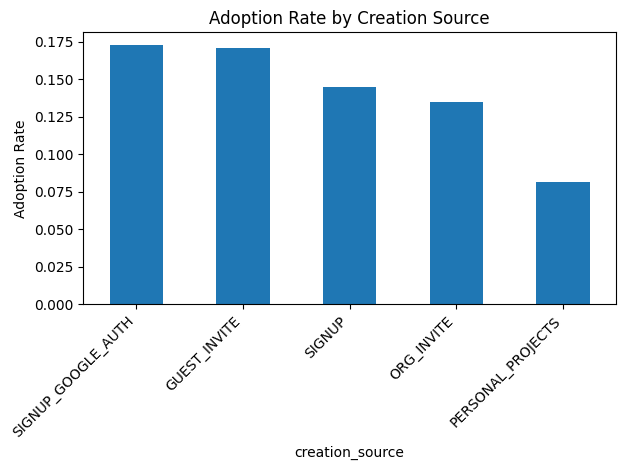

In [21]:
# plot of adoption rate by creation source

import matplotlib.pyplot as plt

adoption_by_source["mean"].plot(kind="bar")
plt.ylabel("Adoption Rate")
plt.title("Adoption Rate by Creation Source")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()